# 00 — Vì sao một tấm ảnh lại tốn hơn một nghìn token

Notebook này giải thích nền tảng của dự án `vlm-speedrun`, bằng cách đo trực tiếp
trên máy bạn chứ không nói suông. Giả định: bạn đã quen Transformer, attention,
và vòng lặp huấn luyện. Không giả định bạn biết gì về mô hình thị giác–ngôn ngữ.

Nội dung:
1. Mô hình thị giác–ngôn ngữ nhìn thấy gì
2. Đếm token ảnh trên máy bạn
3. Đo thời gian cho đúng
4. Thời gian thực sự nằm ở đâu
5. Hệ quả: nên tối ưu chỗ nào

## 1. Mô hình thị giác–ngôn ngữ nhìn thấy gì

Một mô hình ngôn ngữ chỉ nhận **một chuỗi vector**. Nó không có khái niệm "ảnh".
Vậy để đưa ảnh vào, người ta phải biến ảnh thành một chuỗi vector cùng chiều với
embedding của chữ, rồi **chèn thẳng vào chuỗi**.

SmolVLM làm việc đó qua ba bước:

| Bước | Việc làm | Kết quả với một ảnh |
|---|---|---|
| Cắt ô | chia ảnh thành các ô vuông 384×384, cộng thêm một ô thu nhỏ toàn ảnh | 13 ô |
| Mã hoá thị giác | mỗi ô đi qua một Vision Transformer, thành 729 patch × 1152 chiều | 13 × 729 vector |
| Connector | nén 9 patch liền kề thành 1 (kỹ thuật *pixel shuffle*), đồng thời đổi chiều sang 2048 | 13 × 81 = **1053 token** |

Con số 729 đến từ đâu: ô 384×384 chia thành patch 14×14 cho lưới 27×27, và 27² = 729.
Con số 81 đến từ 729 ÷ 9 = 81.

**Điểm mấu chốt:** 1053 token ảnh này nằm *cùng một chuỗi* với token chữ. Với mô
hình ngôn ngữ, chúng không khác gì 1053 chữ.

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

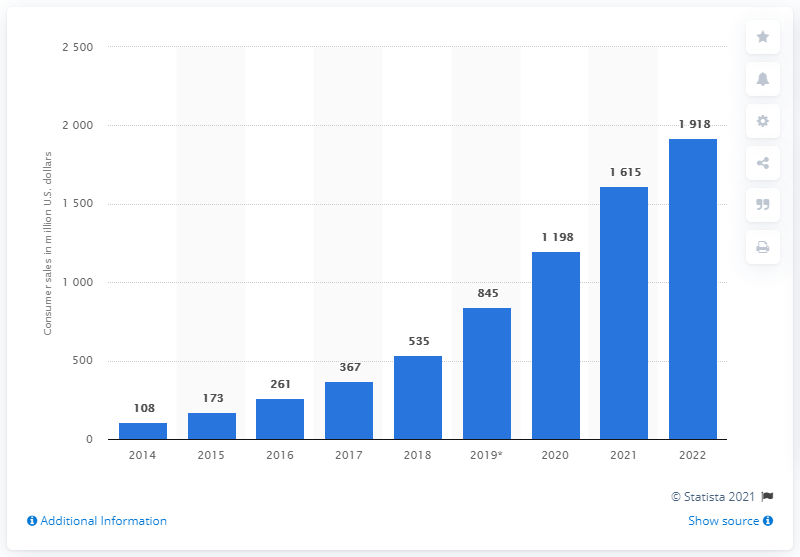

In [1]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText
from bench.harness import load_samples, PROMPT

MODEL = "HuggingFaceTB/SmolVLM-Instruct"
proc = AutoProcessor.from_pretrained(MODEL)
model = AutoModelForImageTextToText.from_pretrained(MODEL, dtype=torch.bfloat16).to("cuda").eval()

sample = load_samples(1, seed=0)[0]
sample["image"]

## 2. Đếm token ảnh trên máy bạn

In [2]:
msg = [{"role": "user", "content": [{"type": "image"},
                                    {"type": "text", "text": PROMPT.format(q=sample["query"])}]}]
text = proc.apply_chat_template(msg, add_generation_prompt=True)
inputs = proc(text=text, images=[sample["image"]], return_tensors="pt").to("cuda")

ids = inputs["input_ids"][0]
n_img = int((ids == model.config.image_token_id).sum())
print("kích thước ảnh gốc :", sample["image"].size)
print("số ô sau khi cắt   :", inputs["pixel_values"].shape[1])
print("tổng token đầu vào :", ids.numel())
print(f"token ảnh          : {n_img}  ({100*n_img/ids.numel():.1f}% toàn chuỗi)")
print("token chữ          :", ids.numel() - n_img)

kích thước ảnh gốc : (800, 557)
số ô sau khi cắt   : 13
tổng token đầu vào : 1251
token ảnh          : 1053  (84.2% toàn chuỗi)
token chữ          : 198


Chạy trên máy dùng để viết notebook này, kết quả là **1053 token ảnh trên tổng
1251 token**, tức ảnh chiếm **84,2%** chuỗi. Toàn bộ câu hỏi, khuôn mẫu hội thoại
và chỉ dẫn cộng lại chỉ tốn 198 token.

Đây là lý do mọi kỹ thuật tăng tốc mô hình thị giác–ngôn ngữ đều bắt đầu từ token ảnh.

## 3. Đo thời gian cho đúng

Trước khi tối ưu bất cứ thứ gì, phải đo được. Và đo GPU có ba cái bẫy:

**Bẫy 1 — bất đồng bộ.** Lệnh gọi CUDA trả về ngay lập tức, trong khi GPU vẫn đang
tính. Dùng `time.time()` là đo thời gian *xếp lệnh*, không phải thời gian *chạy*.
Cách đúng: dùng CUDA event, hoặc gọi `torch.cuda.synchronize()` trước khi bấm giờ.

**Bẫy 2 — lần chạy đầu luôn chậm.** Lần đầu phải cấp phát bộ nhớ, biên dịch kernel,
nạp trọng số vào cache. Phải chạy làm nóng vài lần rồi mới đo.

**Bẫy 3 — máy nóng lên thì chậm đi.** Trên GPU laptop, xung nhịp tụt khi nhiệt tăng.
Nếu chạy hết cấu hình A rồi mới chạy B, thì B luôn chạy trên một cái máy nóng hơn.

In [3]:
import statistics, torch

def timed(fn):
    """Bấm giờ bằng CUDA event — cách duy nhất đúng khi đo GPU."""
    start, end = torch.cuda.Event(True), torch.cuda.Event(True)
    torch.cuda.synchronize(); start.record()
    out = fn(); end.record(); torch.cuda.synchronize()
    return start.elapsed_time(end), out

gen = lambda: model.generate(**inputs, max_new_tokens=32, do_sample=False)

with torch.no_grad():
    for _ in range(5):          # làm nóng
        gen()
    xs = [timed(gen)[0] for _ in range(20)]

xs_sorted = sorted(xs)
med = statistics.median(xs)
iqr = xs_sorted[15] - xs_sorted[5]
print(f"trung vị {med:.1f} ms | IQR {iqr:.1f} ms ({100*iqr/med:.1f}% trung vị)")
print(f"min {min(xs):.1f} | max {max(xs):.1f} ms")

trung vị 899.7 ms | IQR 22.8 ms (2.5% trung vị)
min 846.4 | max 932.3 ms


**Vì sao báo cáo trung vị và IQR, không báo cáo trung bình ± độ lệch chuẩn:**
phân bố độ trễ lệch phải — thỉnh thoảng có một lần chạy rất chậm do hệ điều hành
xen vào. Trung bình bị những lần đó kéo lên, trung vị thì không.

## 4. Thời gian thực sự nằm ở đâu

Đây là phần đảo ngược trực giác. Vì token ảnh chiếm hơn 90% chuỗi, ta dễ nghĩ mô
hình ngôn ngữ là chỗ tốn thời gian. Hãy đo thay vì đoán.

In [4]:
inner = model.model
with torch.no_grad():
    t_vis, out = timed(lambda: inner.vision_model(
        pixel_values=inputs["pixel_values"].flatten(0, 1).to(model.dtype)))
    vis = out.last_hidden_state
    t_con, feats = timed(lambda: inner.connector(vis))
    t_pre, _ = timed(lambda: model(**inputs))
    t_gen, _ = timed(gen)

print(f"mã hoá thị giác : {t_vis:6.1f} ms  ({100*t_vis/t_gen:4.1f}%)")
print(f"connector       : {t_con:6.1f} ms  ({100*t_con/t_gen:4.1f}%)")
print(f"prefill ngôn ngữ: {t_pre-t_vis-t_con:6.1f} ms  ({100*(t_pre-t_vis-t_con)/t_gen:4.1f}%)")
print(f"sinh 32 token   : {t_gen-t_pre:6.1f} ms  ({100*(t_gen-t_pre)/t_gen:4.1f}%)")
print(f"tổng            : {t_gen:6.1f} ms")

mã hoá thị giác :  502.0 ms  (53.8%)
connector       :    2.7 ms  ( 0.3%)
prefill ngôn ngữ:  276.5 ms  (29.6%)
sinh 32 token   :  152.6 ms  (16.3%)
tổng            :  933.9 ms


Kết quả đo được trên GPU RTX 1000 Ada 6 GB:

| Thành phần | Thời gian | Tỉ lệ |
|---|---|---|
| Bộ mã hoá thị giác | 502 ms | **53,8%** |
| Connector | 2,7 ms | 0,3% |
| Prefill của mô hình ngôn ngữ | 277 ms | 29,6% |
| Sinh 32 token | 153 ms | 16,3% |

(Một script đo riêng trên 12 mẫu × 3 lần cho kết quả khớp: 52,7% / 0,3% / 29,3% / 16,5%.)

**Hơn một nửa thời gian nằm ở bộ mã hoá thị giác**, chứ không phải ở mô hình ngôn ngữ.
Lý do: 13 ô ảnh, mỗi ô là một lượt chạy Vision Transformer đầy đủ.

## 5. Hệ quả: nên tối ưu chỗ nào

Gọi **p** là tỉ lệ thời gian của phần ta tối ưu được. Định luật Amdahl nói mức tăng
tốc tối đa khi làm phần đó nhanh vô hạn là:

    tăng tốc tối đa = 1 / (1 − p)

Áp vào hai đòn bẩy:

| Đòn bẩy | Tấn công phần nào | p | Trần lý thuyết | Đo thực tế |
|---|---|---|---|---|
| Cắt token sau khi mã hoá | chỉ prefill ngôn ngữ | 0,296 | **1,42×** | 1,13–1,26× |
| Giảm số ô ảnh | cả mã hoá thị giác lẫn prefill | 0,84 | **6,1×** | **1,93×** (cạnh 768) |

Vì sao thực tế chỉ đạt 1,93× dù trần là 6,1×: giảm cạnh dài từ 1536 xuống 768 không
làm bộ mã hoá thị giác biến mất, chỉ giảm số ô từ 13 xuống 5. Trần lý thuyết ứng với
trường hợp phần đó bằng không.

Bài học: **đếm token không cho biết thời gian nằm ở đâu.** Ảnh chiếm 91,6% số token
nhưng phần token đó chỉ chi phối 29,3% thời gian, vì chi phí tạo ra chúng mới là
phần đắt. Cắt token sau khi đã trả tiền mã hoá là đóng cửa chuồng sau khi ngựa đã chạy.

Một kết quả nữa, đo trên 300 mẫu với kiểm định McNemar theo cặp: giảm cạnh dài
xuống 768 cho **1,93× tốc độ** nhưng **mất 7,3 điểm độ chính xác** (p = 0,002).
Đây là một đánh đổi thật, không phải bữa trưa miễn phí.

Notebook 01 sẽ đi vào cách bố trí thí nghiệm so sánh cho công bằng — gồm hai lỗi đo
đạc tôi đã mắc trong dự án này, và lần kết luận bị đảo ngược khi tăng số mẫu.